## **<span style="color:red">ii. Missing Value Imputation</span>**

<br>

#### **<span style="color:black">- Dataset</span>**

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('gurgaon_properties_outlier_treated.csv')
df.shape            # 177 Outliers have been Removed in the previous Step

(3498, 22)

In [5]:
df.head(3)

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category,area_room_ratio
0,flat,sector 36,0.82,7586.0,1081.0,3,2,2,NaN,New Property,1081.0,NaN,650.0,0,0,0,0,0,semifurnished,Low Floor,Low,360.333333
1,flat,sector 89,0.95,8597.0,1105.0,2,2,2,NaN,New Property,NaN,NaN,1103.0,1,1,0,0,0,semifurnished,Mid Floor,Low,552.500000
2,flat,sohna road,0.32,5470.0,585.0,2,2,1,NaN,New Property,NaN,1000.0,585.0,0,0,0,0,0,semifurnished,High Floor,Low,292.500000


In [6]:
df.isnull().sum()

property_type             0
sector                    0
price                     0
price_per_sqft            0
area                      0
bedRoom                   0
bathroom                  0
balcony                   0
facing                  995
agePossession             0
super_built_up_area    1624
built_up_area          1964
carpet_area            1666
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
floor_category           17
luxury_category           0
area_room_ratio           0
dtype: int64

<br>

#### **<span style="color:black">1. Built up area</span>**

<br>

##### **<span style="color:blue">i. Visualization</span>**

In [ ]:
sns.scatterplot(data=df, x='built_up_area', y='price')

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

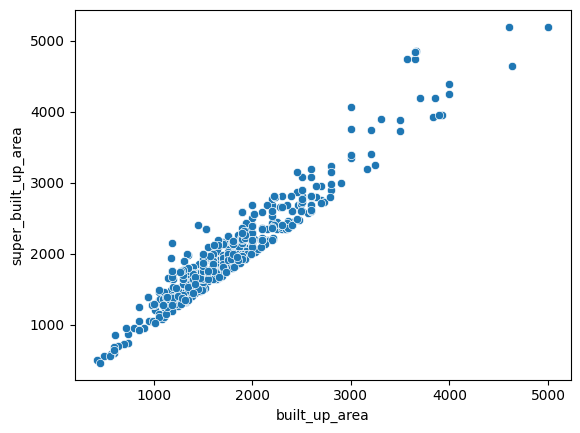

In [7]:
sns.scatterplot(data=df, x='built_up_area', y='super_built_up_area')

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

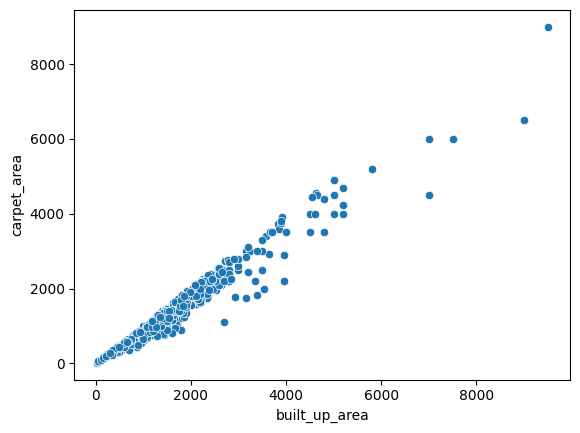

In [8]:
sns.scatterplot(data=df, x='built_up_area', y='carpet_area')

<br>

##### **<span style="color:blue">ii. ALL 3 Present</span>**

Keeps only those rows where none of the three columns (super_built_up_area, built_up_area, carpet_area) are null.

In [9]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]
len(all_present_df)

531

In [11]:
all_present_df.head(3)

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category,area_room_ratio
3,flat,sector 92,1.60,8020.0,1995.0,3,4,3+,North-West,Relatively New,1995.0,1615.0,1476.0,0,1,0,0,1,furnished,Mid Floor,High,665.0
15,flat,sector 85,1.09,6667.0,1635.0,2,2,3,South-West,Relatively New,1640.0,1638.0,1635.0,0,0,1,0,0,semifurnished,Mid Floor,High,817.5
16,flat,sector 70a,1.15,11500.0,1000.0,2,2,3,East,New Property,1450.0,1400.0,1000.0,0,0,0,1,0,semifurnished,Mid Floor,Medium,500.0


<br>

##### **<span style="color:blue">iii. Estimates missing of 'built-up area'</span>**

<br>

###### **<span style="color:green">👉 Finding the perfect Ratios</span>**

We will estimates missing built-up area using known relationships with super built-up and carpet area, then updates the dataset.

In [13]:
# Calculate median ratio of 'super built-up' area to 'built-up' area   (will use as a reference to estimate missing values)
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()
super_to_built_up_ratio

np.float64(1.105263157894737)

In [14]:
# Calculate median ratio of carpet area to built-up area
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()
carpet_to_built_up_ratio

np.float64(0.9)

<br>

###### **<span style="color:green">👉 We will fill missing built_up_area using:</span>**

- super_built_up_area is present
- built_up_area is missing
-  carpet_area is present

In [15]:
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]
sbc_df.head(3)

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category,area_room_ratio
0,flat,sector 36,0.82,7586.0,1081.0,3,2,2,NaN,New Property,1081.0,NaN,650.0,0,0,0,0,0,semifurnished,Low Floor,Low,360.333333
4,flat,sector 102,0.48,9023.0,532.0,2,2,1,North-East,Relatively New,632.0,NaN,532.0,0,0,1,0,0,semifurnished,Mid Floor,High,266.000000
37,flat,sector 37c,1.25,7176.0,1742.0,3,3,3,North-West,Relatively New,1735.0,NaN,1400.0,1,0,0,0,0,semifurnished,Low Floor,Low,580.666667


We will fill missing built_up_area using:

- super_built_up_area (adjusted by dividing ~1.105 i.e super_to_built_up_ratio)
- carpet_area (adjusted by dividing ~0.9 i.e carpet_to_built_up_ratio)
- Then take average of both estimates

In [17]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/super_to_built_up_ratio) + (sbc_df['carpet_area']/carpet_to_built_up_ratio))/2),inplace=True)
sbc_df.head(3)

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category,area_room_ratio
0,flat,sector 36,0.82,7586.0,1081.0,3,2,2,NaN,New Property,1081.0,850.0,650.0,0,0,0,0,0,semifurnished,Low Floor,Low,360.333333
4,flat,sector 102,0.48,9023.0,532.0,2,2,1,North-East,Relatively New,632.0,581.0,532.0,0,0,1,0,0,semifurnished,Mid Floor,High,266.000000
37,flat,sector 37c,1.25,7176.0,1742.0,3,3,3,North-West,Relatively New,1735.0,1563.0,1400.0,1,0,0,0,0,semifurnished,Low Floor,Low,580.666667


Update original dataframe with the filled values

In [18]:
df.update(sbc_df)

In [19]:
df.isnull().sum()

property_type             0
sector                    0
price                     0
price_per_sqft            0
area                      0
bedRoom                   0
bathroom                  0
balcony                   0
facing                  995
agePossession             0
super_built_up_area    1624
built_up_area          1543
carpet_area            1666
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
floor_category           17
luxury_category           0
area_room_ratio           0
dtype: int64

| Feature        | Null Values (Before) | Null Values (After) | Reduction |
|---------------|---------------------|--------------------|-----------|
| built_up_area | 1964                | 1543               | 421       |

<br>

###### **<span style="color:green">👉 We will fill missing built_up_area using:</span>**

- super_built_up_area is present
- built_up_area is missing
- carpet_area is also missing

In [20]:
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]
sb_df.head(3)

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category,area_room_ratio
5,flat,gwal pahari,7.5,14019.0,5350.0,4,4,3+,North-East,New Property,5350.0,NaN,NaN,0,1,0,1,1,furnished,High Floor,Low,1337.500000
6,flat,sector 108,2.0,8554.0,2338.0,3,3,3+,East,Relatively New,2338.0,NaN,NaN,0,1,0,0,0,semifurnished,High Floor,Medium,779.333333
7,flat,sector 102,1.9,9104.0,2087.0,3,4,3,North-East,Relatively New,1889.0,NaN,NaN,0,1,0,0,0,semifurnished,Mid Floor,High,695.666667


We will fill missing built_up_area using:

- only super_built_up_area
- Convert it using approximate ratio (super ≈ super_to_built_up_ratio × built-up)

In [21]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/super_to_built_up_ratio),inplace=True)
sb_df.head(3)

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category,area_room_ratio
5,flat,gwal pahari,7.5,14019.0,5350.0,4,4,3+,North-East,New Property,5350.0,4840.0,NaN,0,1,0,1,1,furnished,High Floor,Low,1337.500000
6,flat,sector 108,2.0,8554.0,2338.0,3,3,3+,East,Relatively New,2338.0,2115.0,NaN,0,1,0,0,0,semifurnished,High Floor,Medium,779.333333
7,flat,sector 102,1.9,9104.0,2087.0,3,4,3,North-East,Relatively New,1889.0,1709.0,NaN,0,1,0,0,0,semifurnished,Mid Floor,High,695.666667


Update the original dataframe with the filled values

In [22]:
df.update(sb_df)

In [23]:
df.isnull().sum()

property_type             0
sector                    0
price                     0
price_per_sqft            0
area                      0
bedRoom                   0
bathroom                  0
balcony                   0
facing                  995
agePossession             0
super_built_up_area    1624
built_up_area           669
carpet_area            1666
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
floor_category           17
luxury_category           0
area_room_ratio           0
dtype: int64

| Feature        | Null Values (Before) | Null Values (After) | Reduction |
|---------------|---------------------|--------------------|-----------|
| built_up_area | 1543                | 669               | 874       |

<br>

###### **<span style="color:green">👉 We will fill missing built_up_area using:</span>**

- super_built_up_area is missing
- built_up_area is missing
- carpet_area is present

In [24]:
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]
c_df.head(3)

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category,area_room_ratio
1,flat,sector 89,0.95,8597.0,1105.0,2,2,2,NaN,New Property,NaN,NaN,1103.0,1,1,0,0,0,semifurnished,Mid Floor,Low,552.50
10,flat,sector 28,1.60,14545.0,1100.0,2,2,2,North,Relatively New,NaN,NaN,1100.0,0,0,0,0,0,semifurnished,Mid Floor,Medium,550.00
12,flat,sector 65,2.77,14025.0,1975.0,4,4,3+,North-East,Relatively New,NaN,NaN,1975.0,1,1,0,0,0,unfurnished,Mid Floor,High,493.75


We will fill missing built_up_area using:

- only carpet_area
- Convert it using approximate ratio (carpet ≈ carpet_to_built_up_ratio × built-up)

In [25]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/carpet_to_built_up_ratio),inplace=True)
c_df.head(3)

,property_type,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category,area_room_ratio
1,flat,sector 89,0.95,8597.0,1105.0,2,2,2,NaN,New Property,NaN,1226.0,1103.0,1,1,0,0,0,semifurnished,Mid Floor,Low,552.50
10,flat,sector 28,1.60,14545.0,1100.0,2,2,2,North,Relatively New,NaN,1222.0,1100.0,0,0,0,0,0,semifurnished,Mid Floor,Medium,550.00
12,flat,sector 65,2.77,14025.0,1975.0,4,4,3+,North-East,Relatively New,NaN,2194.0,1975.0,1,1,0,0,0,unfurnished,Mid Floor,High,493.75


Update the original dataframe with the filled values

In [26]:
df.update(c_df)

In [27]:
df.isnull().sum()

property_type             0
sector                    0
price                     0
price_per_sqft            0
area                      0
bedRoom                   0
bathroom                  0
balcony                   0
facing                  995
agePossession             0
super_built_up_area    1624
built_up_area             0
carpet_area            1666
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
floor_category           17
luxury_category           0
area_room_ratio           0
dtype: int64

| Feature        | Null Values (Before) | Null Values (After) | Reduction |
|---------------|---------------------|--------------------|-----------|
| built_up_area | 669                | 0               | 669       |

<br>

##### **<span style="color:blue">iv. Other Anomalies</span>**

**<span style="color:green">👉 Identify anomalous properties where:</span>**

- built_up_area is very small (< 2000 sqft)
- but price is very high (> 2.5 crore)
- These are likely incorrect entries

In [28]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]
anamoly_df.sample(5)

,price,area,built_up_area
3299,4.70,2380.0,1761.0
34,8.25,2160.0,300.0
1122,2.90,2003.0,1812.0
1334,2.98,2047.0,1852.0
3021,3.50,1449.0,1449.0


Fix the anomaly by replacing built_up_area with 'area'    --> Assumption: 'area' column has the correct value

In [29]:
anamoly_df['built_up_area'] = anamoly_df['area']

Update the original dataframe with corrected values

In [30]:
df.update(anamoly_df)

<br>

##### **<span style="color:blue">iv. Visualization after Filling Missing values</span>**

<Axes: xlabel='built_up_area', ylabel='price'>

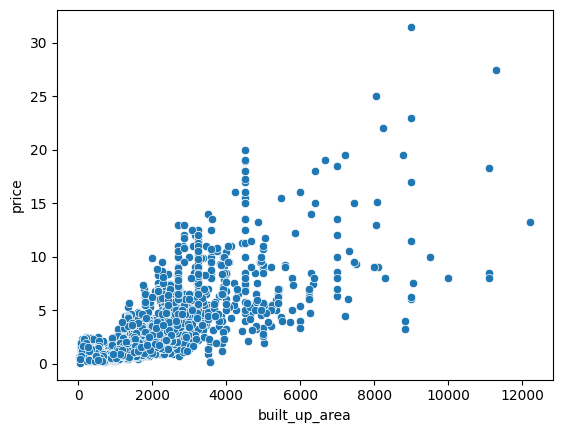

In [32]:
sns.scatterplot(data=df, x='built_up_area', y='price')

<br>

##### **<span style="color:blue">v. Droping Features</span>**

In [35]:
df.drop(columns=['area','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)
df.head(3)

,property_type,sector,price,price_per_sqft,bedRoom,bathroom,balcony,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
0,flat,sector 36,0.82,7586.0,3,2,2,NaN,New Property,850.0,0,0,0,0,0,semifurnished,Low Floor,Low
1,flat,sector 89,0.95,8597.0,2,2,2,NaN,New Property,1226.0,1,1,0,0,0,semifurnished,Mid Floor,Low
2,flat,sohna road,0.32,5470.0,2,2,1,NaN,New Property,1000.0,0,0,0,0,0,semifurnished,High Floor,Low


In [36]:
df.isnull().sum()

property_type        0
sector               0
price                0
price_per_sqft       0
bedRoom              0
bathroom             0
balcony              0
facing             995
agePossession        0
built_up_area        0
study room           0
servant room         0
store room           0
pooja room           0
others               0
furnishing_type      0
floor_category      17
luxury_category      0
dtype: int64

<br>

#### **<span style="color:black">2. floor_category</span>**

In [37]:
df.head(3)

,property_type,sector,price,price_per_sqft,bedRoom,bathroom,balcony,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
0,flat,sector 36,0.82,7586.0,3,2,2,NaN,New Property,850.0,0,0,0,0,0,semifurnished,Low Floor,Low
1,flat,sector 89,0.95,8597.0,2,2,2,NaN,New Property,1226.0,1,1,0,0,0,semifurnished,Mid Floor,Low
2,flat,sohna road,0.32,5470.0,2,2,1,NaN,New Property,1000.0,0,0,0,0,0,semifurnished,High Floor,Low


We will firstly analyse 'floor_category' feature where it is NULL

In [39]:
df[df['floor_category'].isnull()].head(3)

,property_type,sector,price,price_per_sqft,bedRoom,bathroom,balcony,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
492,house,sector 4,0.65,11111.0,4,2,2,NaN,Moderately Old,585.0,0,0,0,0,0,semifurnished,NaN,Low
755,house,sector 7,6.50,15046.0,3,2,3+,NaN,Old Property,4320.0,0,0,0,0,0,semifurnished,NaN,Low
1271,house,sector 3,1.50,10288.0,3,3,0,NaN,Old Property,210.0,0,0,0,0,0,semifurnished,NaN,Low


Mostly 'floor_category' is NULL for 'house' property_type

So We will perform Mode value Imputation

In [41]:
df[df['property_type'] == 'house']['floor_category'].mode()[0]

'Low Floor'

In [42]:
df['floor_category'] = df['floor_category'].fillna(df[df['property_type'] == 'house']['floor_category'].mode()[0])

In [43]:
df.isnull().sum()

property_type        0
sector               0
price                0
price_per_sqft       0
bedRoom              0
bathroom             0
balcony              0
facing             995
agePossession        0
built_up_area        0
study room           0
servant room         0
store room           0
pooja room           0
others               0
furnishing_type      0
floor_category       0
luxury_category      0
dtype: int64

<br>

#### **<span style="color:black">3. facing</span>**

<Axes: ylabel='count'>

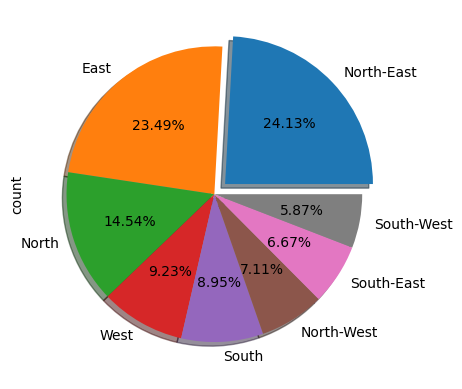

In [45]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%', shadow=True, explode=(0.1, 0, 0, 0, 0, 0, 0, 0) )

In [46]:
df.drop(columns=['facing'],inplace=True)

In [47]:
df.sample(5)

,property_type,sector,price,price_per_sqft,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
2249,flat,sector 102,1.35,10800.0,3,4,3+,Relatively New,1400.0,0,1,0,1,0,furnished,Mid Floor,High
3161,flat,sector 65,5.00,18519.0,3,3,3+,Relatively New,2800.0,0,1,0,1,0,furnished,High Floor,High
2844,flat,sector 82a,2.95,11452.0,4,5,3+,Relatively New,2110.0,0,1,0,0,0,unfurnished,Mid Floor,High
939,flat,sector 109,1.75,10029.0,3,3,3,Relatively New,1550.0,0,0,0,1,0,furnished,Mid Floor,Low
926,house,sector 2,9.00,19231.0,5,5,2,Old Property,4680.0,1,1,1,1,0,unfurnished,Low Floor,Medium


In [48]:
df.isnull().sum()

property_type      0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
floor_category     0
luxury_category    0
dtype: int64

<br>

#### **<span style="color:black">4. agePossession</span>**

<br>

##### **<span style="color:blue">i. Basic Analysis</span>**

In [49]:
df['agePossession'].value_counts()

agePossession
Relatively New        1593
New Property           551
Moderately Old         522
Undefined              289
Old Property           279
Under Construction     264
Name: count, dtype: int64

In [50]:
df[df['agePossession'] == 'Undefined']

,property_type,sector,price,price_per_sqft,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
9,house,sector 109,1.55,6568.0,3,2,0,Undefined,2360.0,0,0,0,0,0,semifurnished,Low Floor,Low
32,house,sector 89,0.70,5397.0,2,2,2,Undefined,1297.0,0,0,0,0,0,semifurnished,High Floor,Low
46,flat,sector 89,1.71,12000.0,3,2,0,Undefined,1423.0,0,0,0,0,0,semifurnished,Mid Floor,Low
67,flat,sector 102,0.45,6000.0,1,1,2,Undefined,750.0,0,0,0,0,0,semifurnished,Mid Floor,Low
71,house,sector 3,1.50,7576.0,7,2,0,Undefined,1980.0,0,0,0,0,0,semifurnished,Low Floor,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3445,flat,sector 37d,1.10,9839.0,2,2,2,Undefined,1242.0,0,0,0,0,0,semifurnished,Mid Floor,Medium
3451,house,sector 21,0.45,8411.0,3,2,1,Undefined,594.0,0,0,0,0,0,semifurnished,Low Floor,Low
3463,flat,sector 95,0.57,4179.0,2,2,2,Undefined,1364.0,0,0,0,0,0,semifurnished,Mid Floor,Low
3470,house,sector 28,0.45,1111.0,5,3,0,Undefined,50.0,0,0,0,0,0,semifurnished,Low Floor,Low


<br>

##### **<span style="color:blue">ii. Impute using both sector + property_type</span>**

In [51]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
    
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']


df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [52]:
df['agePossession'].value_counts()

agePossession
Relatively New        1702
New Property           591
Moderately Old         556
Old Property           318
Under Construction     278
Undefined               53
Name: count, dtype: int64

| Feature        | Undefined Values (Before) | Undefined Values (After) | Reduction |
|---------------|---------------------|--------------------|-----------|
| agePossession | 289               | 53               | 236       |

<br>

##### **<span style="color:blue">iii. Impute using only sector</span>**

In [53]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']
    
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [54]:
df['agePossession'].value_counts()

agePossession
Relatively New        1711
New Property           592
Moderately Old         559
Old Property           321
Under Construction     278
Undefined               37
Name: count, dtype: int64

| Feature        | Undefined Values (Before) | Undefined Values (After) | Reduction |
|---------------|---------------------|--------------------|-----------|
| agePossession | 53               | 37               | 16       |

<br>

##### **<span style="color:blue">iii. Impute using only property_type</span>**

In [55]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']
    
    
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [56]:
df['agePossession'].value_counts()

agePossession
Relatively New        1713
Moderately Old         594
New Property           592
Old Property           321
Under Construction     278
Name: count, dtype: int64

| Feature        | Undefined Values (Before) | Undefined Values (After) | Reduction |
|---------------|---------------------|--------------------|-----------|
| agePossession | 37               | 0               | 37       |

<br>

## **<span style="color:black">- Saving Dataset </span>**

In [57]:
df.isnull().sum()

property_type      0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
floor_category     0
luxury_category    0
dtype: int64

In [58]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)

In [59]:
df.shape

(3498, 17)